# Лабораторная 3 — Сегментация дорожных знаков + трекинг

**Дедлайн:** 26.02 · **Баллов:** 10

- Предобученные модели детекции (Mask R-CNN и т.п.) детектируют и сегментируют объекты фиксированных классов, в том числе знак «Стоп».
- Предлагается обучить выбранную модель сегментировать **8 типов знаков** на наборе Russian road signs (https://www.kaggle.com/datasets/viacheslavshalamov/russian-road-signs-segmentation-dataset — 100 000 изображений дорожных знаков России, построен на основе детекционного набора MSU https://graphics.cs.msu.ru/projects/traffic-sign-recognition.html).
- Можно использовать MMSegmentation или попробовать YOLOv11 и другие сегментаторы.
- **Тестирование на видео:** 3+ собственных видео по 30+ секунд, снятых у Университета ИТМО (или в других узнаваемых местах, если по уважительным причинам нет другой возможности).
- **Оценка сегментации:** IoU, Precision, Recall, L2 — отдельно на валидационной части и на собственных фото; также интересует % изображений, где IoU ≥ 0.5 / 0.75 / 0.9.
- **Трекинг:** запустить 2 алгоритма (BYTETrack + BoTSORT) на отснятых видео и посчитать **ID Switches**.

> Замечание по реализации: в этом ноутбуке используется готовый YOLO-seg датасет `bogdanliutikov/russian-road-signs-segmentation-dataset` (один класс `road_sign`, все типы знаков схлопнуты), поскольку он лежит уже в нужном формате. Это компромисс между постановкой задачи и наличием готовой разметки.

## Раздел 1: Установка зависимостей и импорты


In [1]:
import subprocess, sys

REQUIRED = ['kaggle', 'motmetrics']
missing = []
for pkg in REQUIRED:
    try:
        __import__(pkg)
    except ImportError:
        missing.append(pkg)

if missing:
    print(f'Installing: {missing}')
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '--quiet', *missing])
else:
    print('All optional packages already installed.')

All optional packages already installed.


In [2]:
import os
import json
import random
import shutil
from pathlib import Path
from collections import defaultdict, Counter

import numpy as np
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Polygon as MplPolygon
from tqdm.auto import tqdm

import torch
from ultralytics import YOLO

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

LAB3_DIR = Path('/home/greg/git/uni/cv/Lab3')
DATA_DIR = LAB3_DIR / 'data'
YOLO_DIR = LAB3_DIR / 'yolo_dataset'
VIDEOS_DIR = LAB3_DIR / 'videos'
PHOTOS_DIR = LAB3_DIR / 'photos'
OUTPUTS_DIR = LAB3_DIR / 'outputs'
RUNS_DIR = LAB3_DIR / 'runs'
for d in (DATA_DIR, YOLO_DIR, VIDEOS_DIR, PHOTOS_DIR, OUTPUTS_DIR, RUNS_DIR):
    d.mkdir(parents=True, exist_ok=True)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'PyTorch  : {torch.__version__}')
print(f'CUDA     : {torch.cuda.is_available()} ({torch.cuda.get_device_name(0) if torch.cuda.is_available() else "—"})')
print(f'Device   : {DEVICE}')
print(f'Lab3 dir : {LAB3_DIR}')

/home/greg/miniconda3/envs/ml/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PyTorch  : 2.5.1+cu121
CUDA     : True (NVIDIA GeForce RTX 4070 Laptop GPU)
Device   : cuda
Lab3 dir : /home/greg/git/uni/cv/Lab3


## Раздел 2: Скачивание и подготовка датасета
### 2a. Скачивание через Kaggle CLI


In [3]:
KAGGLE_DATASET = 'bogdanliutikov/russian-road-signs-segmentation-dataset'
KAGGLE_JSON = Path.home() / '.kaggle' / 'kaggle.json'
KAGGLE_ACCESS_TOKEN = Path.home() / '.kaggle' / 'access_token'

def _kaggle_env():
    env = os.environ.copy()
    if KAGGLE_JSON.exists():
        creds = json.loads(KAGGLE_JSON.read_text())
        env['KAGGLE_USERNAME'] = creds['username']
        env['KAGGLE_KEY'] = creds['key']
        return env
    if KAGGLE_ACCESS_TOKEN.exists():
        env['KAGGLE_KEY'] = KAGGLE_ACCESS_TOKEN.read_text().strip()
        env.setdefault('KAGGLE_USERNAME', 'anonymous')
        return env
    return None

_already = any(DATA_DIR.iterdir()) if DATA_DIR.exists() else False
if _already:
    print(f'Dataset already extracted in {DATA_DIR} — skipping download.')
else:
    env = _kaggle_env()
    if env is None:
        print('!! Kaggle credentials not found.')
        print('   Place either ~/.kaggle/kaggle.json (classic) or ~/.kaggle/access_token (KGAT) then re-run.')
    else:
        print(f'Downloading {KAGGLE_DATASET} → {DATA_DIR}')
        subprocess.check_call(
            ['kaggle', 'datasets', 'download', '-d', KAGGLE_DATASET, '-p', str(DATA_DIR), '--unzip'],
            env=env,
        )
        print('Download complete.')

print('\nTop-level entries in DATA_DIR:')
for p in sorted(DATA_DIR.iterdir())[:20] if DATA_DIR.exists() else []:
    print(f'  {p.name}/' if p.is_dir() else f'  {p.name}')

Dataset already extracted in /home/greg/git/uni/cv/Lab3/data — skipping download.

Top-level entries in DATA_DIR:
  dataset/


  2%|▏         | 13.0M/539M [00:01<00:38, 14.2MB/s]

  3%|▎         | 18.0M/539M [00:01<00:36, 15.0MB/s]

  5%|▍         | 26.0M/539M [00:01<00:26, 20.4MB/s]

  6%|▋         | 35.0M/539M [00:02<00:18, 28.8MB/s]

...

 96%|█████████▌| 516M/539M [00:20<00:00, 36.7MB/s]

 97%|█████████▋| 525M/539M [00:20<00:00, 36.9MB/s]

 99%|█████████▉| 535M/539M [00:20<00:00, 41.6MB/s]

100%|██████████| 539M/539M [00:20<00:00, 27.4MB/s]



Download complete.

Top-level entries in DATA_DIR:
  dataset/


### 2b. Структура скачанного датасета


In [4]:
def print_tree(root: Path, max_depth=3, max_per_dir=8, prefix=''):
    if max_depth < 0 or not root.exists():
        return
    entries = sorted(root.iterdir())
    for i, entry in enumerate(entries[:max_per_dir]):
        connector = '└── ' if i == len(entries[:max_per_dir]) - 1 else '├── '
        print(f'{prefix}{connector}{entry.name}{"/" if entry.is_dir() else ""}')
        if entry.is_dir():
            sub_prefix = prefix + ('    ' if i == len(entries[:max_per_dir]) - 1 else '│   ')
            print_tree(entry, max_depth - 1, max_per_dir, sub_prefix)
    if len(entries) > max_per_dir:
        print(f'{prefix}└── ... ({len(entries) - max_per_dir} more)')

ext_counts = Counter()
if DATA_DIR.exists():
    for p in DATA_DIR.rglob('*'):
        if p.is_file():
            ext_counts[p.suffix.lower()] += 1

print(f'DATA_DIR : {DATA_DIR}')
print(f'File counts by extension: {dict(ext_counts.most_common())}')
print(f'\nTree (depth=3):')
print_tree(DATA_DIR, max_depth=3)

DATA_DIR : /home/greg/git/uni/cv/Lab3/data
File counts by extension: {'.txt': 2181, '.jpg': 2181, '.cache': 2}

Tree (depth=3):
└── dataset/
    ├── images/
    │   ├── train/
    │   │   ├── 1.jpg
    │   │   ├── 10.jpg
    │   │   ├── 100.jpg
    │   │   ├── 1000.jpg
    │   │   ├── 1001.jpg
    │   │   ├── 1002.jpg
    │   │   ├── 1003.jpg
    │   │   └── 1004.jpg
    │   │   └── ... (2046 more)
    │   └── val/
    │       ├── 201.jpg
    │       ├── 202.jpg
    │       ├── 203.jpg
    │       ├── 204.jpg
    │       ├── 205.jpg
    │       ├── 206.jpg
    │       ├── 207.jpg
    │       └── 208.jpg
    │       └── ... (119 more)
    └── labels/
        ├── train/
        │   ├── 1.txt
        │   ├── 10.txt
        │   ├── 100.txt
        │   ├── 1000.txt
        │   ├── 1001.txt
        │   ├── 1002.txt
        │   ├── 1003.txt
        │   └── 1004.txt
        │   └── ... (2046 more)
        ├── train.cache
        ├── val/
        │   ├── 201.txt
        │   ├── 202.txt
        

### 2c. YOLO-seg формат


In [5]:
CLASS_NAMES = ['road_sign']
NUM_CLASSES = len(CLASS_NAMES)

DATASET_ROOT = DATA_DIR / 'dataset'
IMG_EXTS = {'.jpg', '.jpeg', '.png', '.bmp'}

YOLO_DIR = DATASET_ROOT
print(f'YOLO_DIR -> {YOLO_DIR}')

for split in ('train', 'val'):
    n_img = sum(1 for p in (YOLO_DIR / 'images' / split).glob('*') if p.suffix.lower() in IMG_EXTS) if (YOLO_DIR / 'images' / split).exists() else 0
    n_lbl = sum(1 for _ in (YOLO_DIR / 'labels' / split).glob('*.txt')) if (YOLO_DIR / 'labels' / split).exists() else 0
    polys = 0
    for f in (YOLO_DIR / 'labels' / split).glob('*.txt'):
        polys += sum(1 for line in f.read_text().splitlines() if line.strip())
    print(f'  {split}: {n_img} images, {n_lbl} label files, {polys} polygons')

print(f'\n{NUM_CLASSES} class: {CLASS_NAMES}')

YOLO_DIR -> /home/greg/git/uni/cv/Lab3/data/dataset
  train: 2054 images, 2054 label files, 5453 polygons
  val: 127 images, 127 label files, 400 polygons

1 class: ['road_sign']


  train: 2054 images, 2054 label files, 5453 polygons
  val: 127 images, 127 label files, 400 polygons

1 class: ['road_sign']


### 2d. dataset.yaml для YOLO


In [6]:
DATASET_YAML = LAB3_DIR / 'dataset.yaml'

yaml_text = f"""path: {YOLO_DIR}
train: images/train
val: images/val

names:
""" + ''.join(f'  {i}: {name}\n' for i, name in enumerate(CLASS_NAMES))

DATASET_YAML.write_text(yaml_text)
print(yaml_text)

# YOLO dataset config for Russian road signs (1 class)
path: /home/greg/git/uni/cv/Lab3/data/dataset
train: images/train
val: images/val

names:
  0: road_sign



## Раздел 3: Визуализация датасета


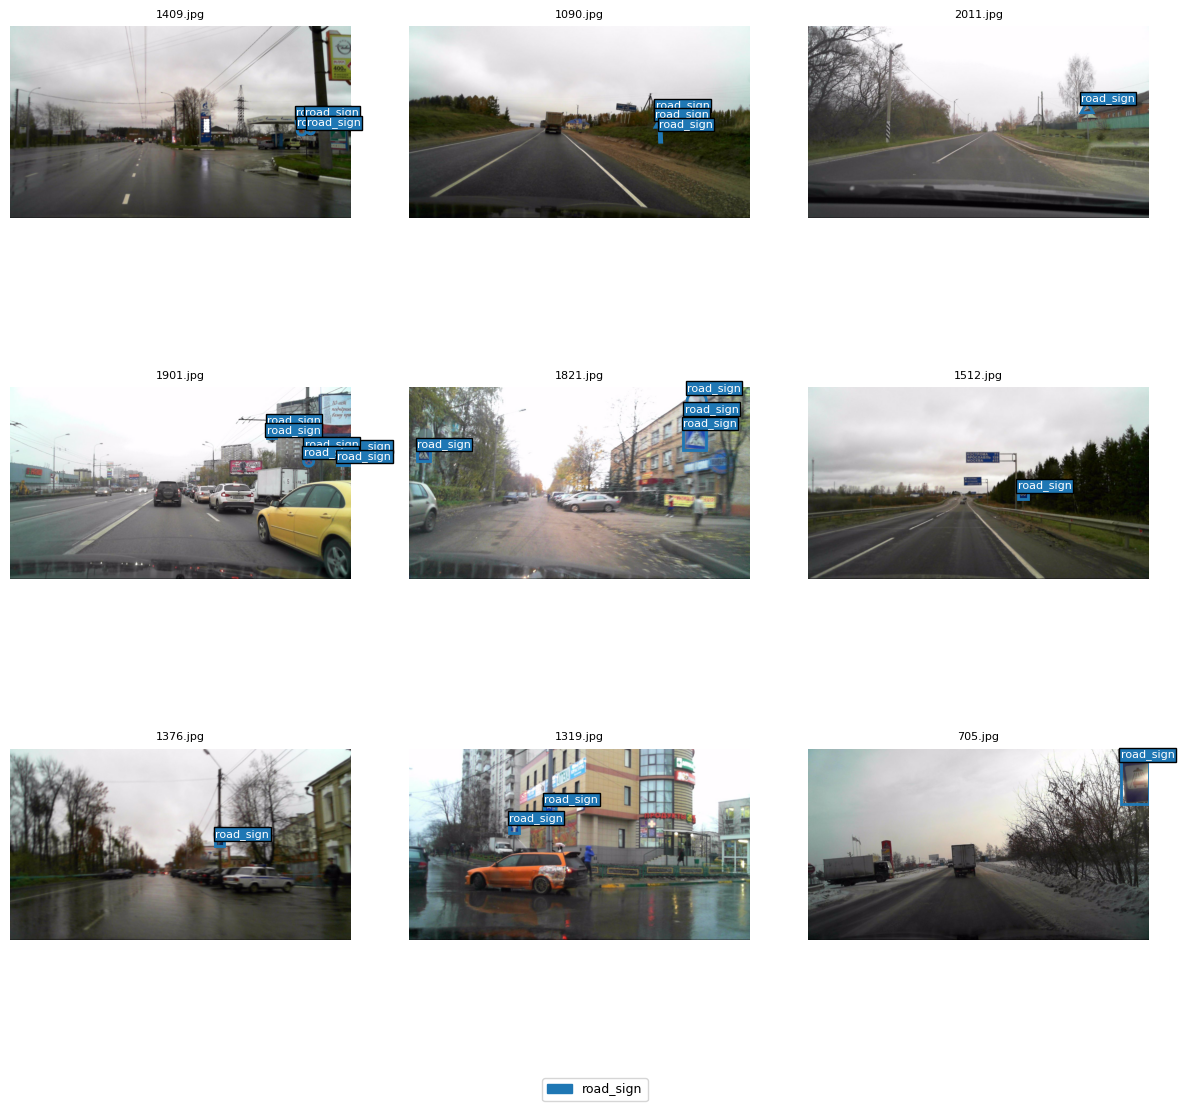

In [7]:
CLASS_COLORS = plt.get_cmap('tab10').colors[:NUM_CLASSES]

def read_yolo_polygons(label_path: Path):
    out = []
    if not label_path.exists():
        return out
    for line in label_path.read_text().strip().splitlines():
        parts = line.split()
        if len(parts) < 7:
            continue
        cid = int(parts[0])
        coords = np.array(parts[1:], dtype=np.float32).reshape(-1, 2)
        out.append((cid, coords))
    return out

def show_dataset_grid(split='train', n=9):
    img_dir = YOLO_DIR / 'images' / split
    lbl_dir = YOLO_DIR / 'labels' / split
    imgs = sorted([p for p in img_dir.iterdir() if p.suffix.lower() in IMG_EXTS]) if img_dir.exists() else []
    if not imgs:
        print(f'No converted {split} images yet — run Section 2 conversion first.')
        return

    rng = random.Random(SEED)
    sample = rng.sample(imgs, min(n, len(imgs)))

    cols = 3
    rows = (len(sample) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 4, rows * 4))
    axes = np.atleast_2d(axes).flatten()
    for ax, img_p in zip(axes, sample):
        img = cv2.imread(str(img_p))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        h, w = img.shape[:2]
        ax.imshow(img)
        for cid, coords in read_yolo_polygons(lbl_dir / f'{img_p.stem}.txt'):
            pix = coords * np.array([w, h])
            poly = MplPolygon(pix, closed=True, fill=False, edgecolor=CLASS_COLORS[cid % NUM_CLASSES], linewidth=2)
            ax.add_patch(poly)
            ax.text(pix[:, 0].min(), pix[:, 1].min() - 4, CLASS_NAMES[cid],
                    color='white', fontsize=8,
                    bbox=dict(facecolor=CLASS_COLORS[cid % NUM_CLASSES], pad=1))
        ax.set_title(img_p.name, fontsize=8)
        ax.axis('off')
    for ax in axes[len(sample):]:
        ax.axis('off')

    handles = [mpatches.Patch(color=CLASS_COLORS[i], label=n) for i, n in enumerate(CLASS_NAMES)]
    fig.legend(handles=handles, loc='lower center', ncol=4, fontsize=9, bbox_to_anchor=(0.5, -0.02))
    plt.tight_layout()
    plt.show()

show_dataset_grid('train', n=9)

## Раздел 4: Обучение YOLO11-seg


In [8]:
NUM_EPOCHS = 30
IMG_SIZE = 640
BATCH = 16
TRAIN_NAME = 'yolo11n_seg'
WORKERS = 2

_existing_best = sorted(RUNS_DIR.glob(f'{TRAIN_NAME}*/weights/best.pt'), key=os.path.getmtime, reverse=True)
train_imgs = list((YOLO_DIR / 'images' / 'train').glob('*')) if (YOLO_DIR / 'images' / 'train').exists() else []
val_imgs = list((YOLO_DIR / 'images' / 'val').glob('*')) if (YOLO_DIR / 'images' / 'val').exists() else []
print(f'train images: {len(train_imgs)}, val images: {len(val_imgs)}')

if _existing_best:
    print(f'Found existing checkpoint {_existing_best[0]} — skipping training (delete runs/ to retrain).')
elif not train_imgs:
    print('Skip training — dataset not present yet.')
else:
    model = YOLO('yolo11n-seg.pt')
    results = model.train(
        data=str(DATASET_YAML),
        epochs=NUM_EPOCHS,
        imgsz=IMG_SIZE,
        batch=BATCH,
        device=0,
        workers=WORKERS,
        project=str(RUNS_DIR),
        name=TRAIN_NAME,
        amp=True,
        patience=10,
        save=True,
        plots=True,
        verbose=False,
        exist_ok=True,
    )
    print(f'Training done. Outputs under {RUNS_DIR / TRAIN_NAME}')

train images: 2054, val images: 127
Found existing checkpoint /home/greg/git/uni/cv/Lab3/runs/yolo11n_seg/weights/best.pt — skipping training (delete runs/ to retrain).


In [9]:
BEST_PT = None
candidates = sorted(RUNS_DIR.glob(f'{TRAIN_NAME}*/weights/best.pt'), key=os.path.getmtime, reverse=True)
if candidates:
    BEST_PT = candidates[0]
    print(f'Best checkpoint: {BEST_PT}')
else:
    print('No best.pt yet — Section 4 has not produced a checkpoint.')

Best checkpoint: /home/greg/git/uni/cv/Lab3/runs/yolo11n_seg/weights/best.pt


## Раздел 5: Оценка (IoU / Precision / Recall / L2 + покрытие по порогу)


In [10]:
if BEST_PT is None:
    print('No checkpoint — skip built-in evaluation.')
    builtin_metrics = None
else:
    model = YOLO(str(BEST_PT))
    builtin_metrics = model.val(data=str(DATASET_YAML), split='val', imgsz=IMG_SIZE,
                                project=str(RUNS_DIR), name=f'{TRAIN_NAME}_val',
                                exist_ok=True, plots=True, verbose=False)
    print(f'Mask  mAP50    : {builtin_metrics.seg.map50:.4f}')
    print(f'Mask  mAP50-95 : {builtin_metrics.seg.map:.4f}')
    print(f'Mask  precision: {builtin_metrics.seg.mp:.4f}')
    print(f'Mask  recall   : {builtin_metrics.seg.mr:.4f}')
    print(f'Box   mAP50    : {builtin_metrics.box.map50:.4f}')

Ultralytics 8.4.21 🚀 Python-3.11.14 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 4070 Laptop GPU, 8188MiB)
YOLO11n-seg summary (fused): 114 layers, 2,834,763 parameters, 0 gradients, 9.6 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 263.2±58.2 MB/s, size: 121.2 KB)
val: Scanning /home/greg/git/uni/cv/Lab3/data/dataset/labels/val.cache... 127 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 127/127 41.0Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 8/8 4.4it/s 1.8s0.2s
                   all        127        400      0.917      0.803       0.89      0.626       0.88      0.762      0.836      0.424
Speed: 1.3ms preprocess, 3.4ms inference, 0.0ms loss, 2.5ms postprocess per image
Results saved to /home/greg/git/uni/cv/Lab3/runs/yolo11n_seg_val
Mask  mAP50    : 0.8360
Mask  mAP50-95 : 0.4235
Mask  precision: 0.8798
Mask  recall   : 0.7625
Box   mAP50    : 0.88

In [11]:
def polygons_to_mask(polys, h, w):
    out = []
    for cid, coords in polys:
        pts = (coords.reshape(-1, 2) * np.array([w, h])).astype(np.int32)
        m = np.zeros((h, w), dtype=np.uint8)
        cv2.fillPoly(m, [pts], 1)
        if m.sum() > 0:
            out.append((cid, m))
    return out

def mask_iou(a, b):
    inter = np.logical_and(a, b).sum()
    union = np.logical_or(a, b).sum()
    return inter / union if union > 0 else 0.0

def mask_centroid(m):
    ys, xs = np.where(m)
    if len(xs) == 0:
        return None
    return np.array([xs.mean(), ys.mean()])

def match_predictions(pred_masks, gt_masks, iou_thresh=0.5):
    if not pred_masks or not gt_masks:
        return []
    iou_table = np.zeros((len(pred_masks), len(gt_masks)))
    for i, (pc, pm) in enumerate(pred_masks):
        for j, (gc, gm) in enumerate(gt_masks):
            if pc != gc:
                continue
            iou_table[i, j] = mask_iou(pm, gm)
    matches = []
    used_p, used_g = set(), set()
    while True:
        i, j = np.unravel_index(np.argmax(iou_table), iou_table.shape)
        if iou_table[i, j] < iou_thresh:
            break
        matches.append((i, j, iou_table[i, j]))
        used_p.add(i); used_g.add(j)
        iou_table[i, :] = 0
        iou_table[:, j] = 0
    return matches

def evaluate_split(model, split='val', limit=None):
    img_dir = YOLO_DIR / 'images' / split
    lbl_dir = YOLO_DIR / 'labels' / split
    imgs = sorted([p for p in img_dir.iterdir() if p.suffix.lower() in IMG_EXTS]) if img_dir.exists() else []
    if limit:
        imgs = imgs[:limit]
    if not imgs:
        print(f'No images in {split} split.')
        return None

    per_image = []
    per_class_ious = defaultdict(list)
    for img_p in tqdm(imgs, desc=f'Eval {split}'):
        img = cv2.imread(str(img_p))
        h, w = img.shape[:2]
        gt_polys = read_yolo_polygons(lbl_dir / f'{img_p.stem}.txt')
        gt_masks = polygons_to_mask(gt_polys, h, w)

        results = model.predict(source=img, imgsz=IMG_SIZE, device=0, verbose=False)[0]
        pred_masks = []
        if results.masks is not None and results.boxes is not None:
            cls = results.boxes.cls.cpu().numpy().astype(int)
            data = results.masks.data.cpu().numpy()
            for k, c in enumerate(cls):
                m = (cv2.resize(data[k], (w, h), interpolation=cv2.INTER_NEAREST) > 0.5).astype(np.uint8)
                if m.sum() > 0:
                    pred_masks.append((int(c), m))

        matches = match_predictions(pred_masks, gt_masks, iou_thresh=0.5)
        ious = [iou for _, _, iou in matches]
        diag = float(np.hypot(h, w))
        l2s = []
        for pi, gi, _ in matches:
            cp = mask_centroid(pred_masks[pi][1])
            cg = mask_centroid(gt_masks[gi][1])
            if cp is not None and cg is not None:
                l2s.append(float(np.linalg.norm(cp - cg) / diag))

        tp = len(matches)
        fp = max(0, len(pred_masks) - tp)
        fn = max(0, len(gt_masks) - tp)
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        per_image.append({
            'image': img_p.name,
            'tp': tp, 'fp': fp, 'fn': fn,
            'precision': precision, 'recall': recall,
            'mean_iou': float(np.mean(ious)) if ious else 0.0,
            'max_iou': float(np.max(ious)) if ious else 0.0,
            'mean_l2_norm': float(np.mean(l2s)) if l2s else float('nan'),
        })
        for (pi, gi, iou) in matches:
            per_class_ious[pred_masks[pi][0]].append(iou)

    mean_iou = float(np.mean([r['mean_iou'] for r in per_image if r['tp'] > 0]) or 0.0)
    mean_prec = float(np.mean([r['precision'] for r in per_image]))
    mean_rec = float(np.mean([r['recall'] for r in per_image]))
    mean_l2 = float(np.nanmean([r['mean_l2_norm'] for r in per_image]))
    pct_iou_50 = 100.0 * sum(1 for r in per_image if r['max_iou'] >= 0.50) / len(per_image)
    pct_iou_75 = 100.0 * sum(1 for r in per_image if r['max_iou'] >= 0.75) / len(per_image)
    pct_iou_90 = 100.0 * sum(1 for r in per_image if r['max_iou'] >= 0.90) / len(per_image)

    summary = {
        'mean_iou': mean_iou,
        'precision': mean_prec,
        'recall': mean_rec,
        'l2_norm': mean_l2,
        'pct_iou_ge_0.50': pct_iou_50,
        'pct_iou_ge_0.75': pct_iou_75,
        'pct_iou_ge_0.90': pct_iou_90,
        'n_images': len(per_image),
    }
    return summary, per_image, per_class_ious

if BEST_PT is None:
    print('No checkpoint — skip custom evaluation.')
    val_summary = None
else:
    model = YOLO(str(BEST_PT))
    val_summary, val_per_image, val_per_class = evaluate_split(model, split='val')
    print('\n=== Custom validation metrics ===')
    for k, v in val_summary.items():
        print(f'  {k:>20s}: {v:.4f}' if isinstance(v, float) else f'  {k:>20s}: {v}')

Eval val: 100%|██████████| 127/127 [00:08<00:00, 14.47it/s]


=== Custom validation metrics ===
              mean_iou: 0.6473
             precision: 0.7460
                recall: 0.6489
               l2_norm: 0.0047
       pct_iou_ge_0.50: 91.3386
       pct_iou_ge_0.75: 25.1969
       pct_iou_ge_0.90: 4.7244
              n_images: 127


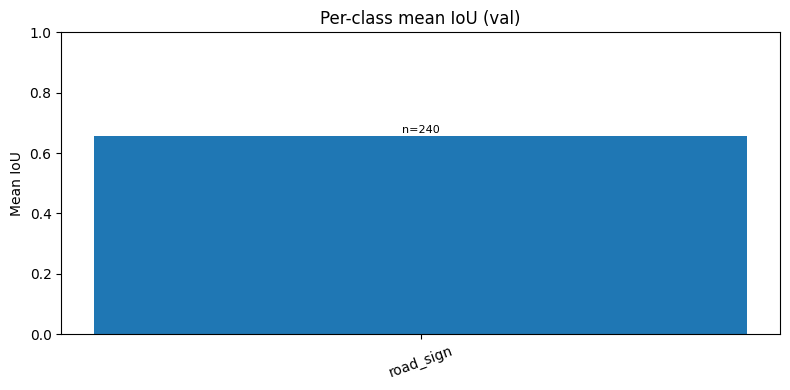

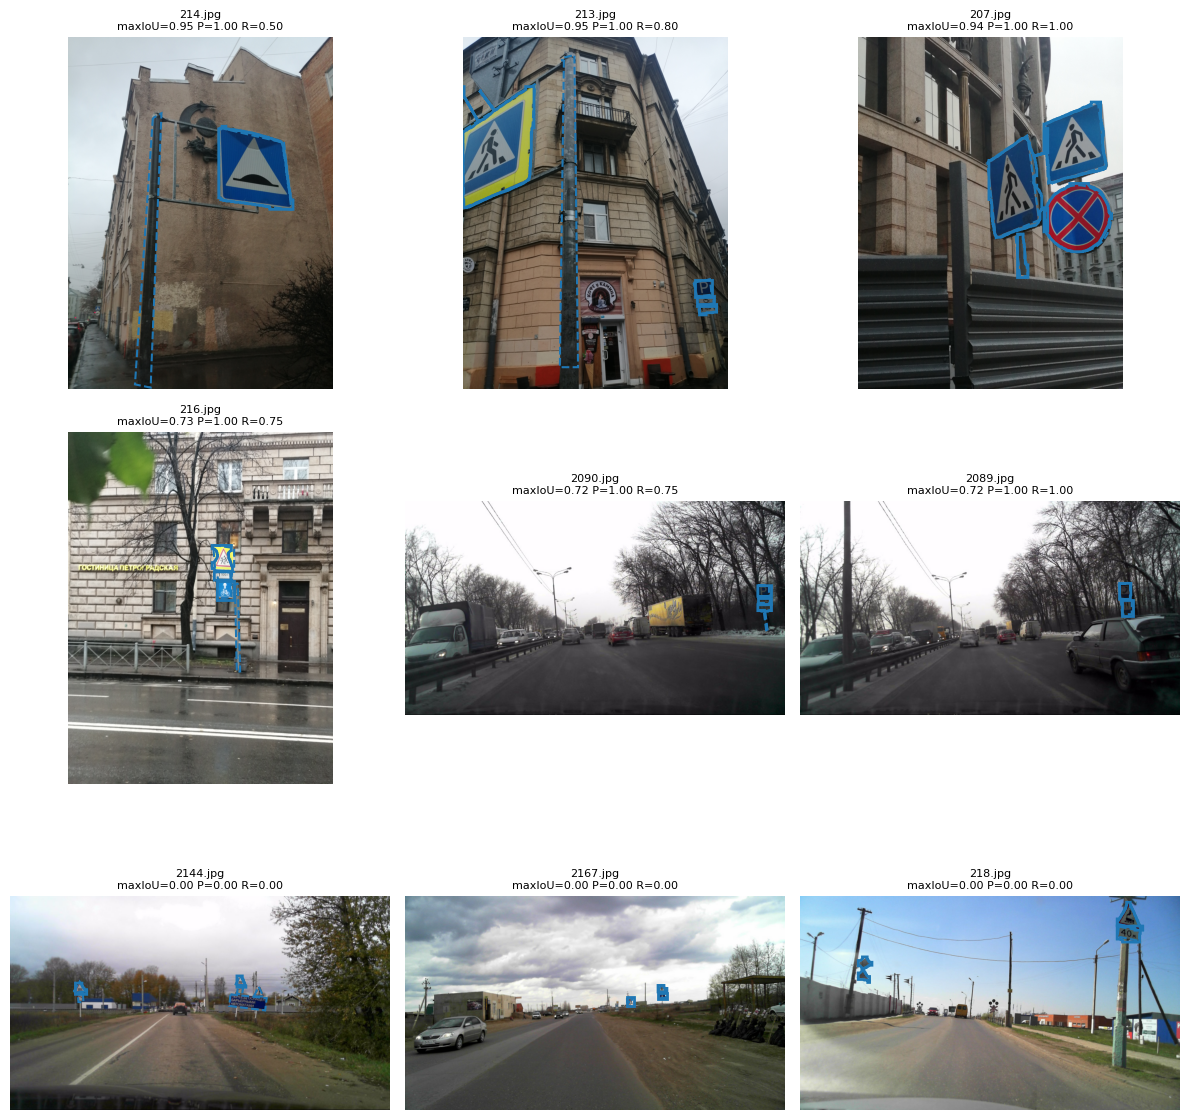

In [12]:
def per_class_bar(per_class_ious, title='Per-class mean IoU (val)'):
    means = [np.mean(per_class_ious.get(i, [0.0])) for i in range(NUM_CLASSES)]
    counts = [len(per_class_ious.get(i, [])) for i in range(NUM_CLASSES)]
    fig, ax = plt.subplots(figsize=(8, 4))
    bars = ax.bar(CLASS_NAMES, means, color=[CLASS_COLORS[i] for i in range(NUM_CLASSES)])
    for b, n in zip(bars, counts):
        ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 0.01, f'n={n}', ha='center', fontsize=8)
    ax.set_ylim(0, 1)
    ax.set_ylabel('Mean IoU')
    ax.set_title(title)
    plt.xticks(rotation=20)
    plt.tight_layout(); plt.show()

def qualitative_grid(model, per_image, n=9, kind='mixed'):
    if kind == 'best':
        picks = sorted(per_image, key=lambda r: -r['max_iou'])[:n]
    elif kind == 'worst':
        picks = sorted(per_image, key=lambda r: r['max_iou'])[:n]
    else:
        srt = sorted(per_image, key=lambda r: -r['max_iou'])
        third = len(srt) // 3
        picks = srt[:n // 3] + srt[third:third + n // 3] + srt[-(n // 3):]

    cols = 3
    rows = (len(picks) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 4, rows * 4))
    axes = np.atleast_2d(axes).flatten()
    for ax, rec in zip(axes, picks):
        img_p = YOLO_DIR / 'images' / 'val' / rec['image']
        img = cv2.cvtColor(cv2.imread(str(img_p)), cv2.COLOR_BGR2RGB)
        h, w = img.shape[:2]
        for cid, coords in read_yolo_polygons(YOLO_DIR / 'labels' / 'val' / f'{img_p.stem}.txt'):
            pix = coords.reshape(-1, 2) * np.array([w, h])
            ax.add_patch(MplPolygon(pix, closed=True, fill=False,
                                     edgecolor=CLASS_COLORS[cid % NUM_CLASSES],
                                     linewidth=1.5, linestyle='--'))
        results = model.predict(source=img_p.as_posix(), imgsz=IMG_SIZE, device=0, verbose=False)[0]
        if results.masks is not None:
            for k in range(len(results.masks)):
                cid = int(results.boxes.cls[k].item())
                poly = results.masks.xy[k]
                ax.add_patch(MplPolygon(poly, closed=True, fill=False,
                                         edgecolor=CLASS_COLORS[cid % NUM_CLASSES],
                                         linewidth=2))
        ax.imshow(img)
        ax.set_title(f"{rec['image']}\nmaxIoU={rec['max_iou']:.2f} P={rec['precision']:.2f} R={rec['recall']:.2f}", fontsize=8)
        ax.axis('off')
    for ax in axes[len(picks):]:
        ax.axis('off')
    plt.tight_layout(); plt.show()

if val_summary is not None:
    per_class_bar(val_per_class)
    qualitative_grid(YOLO(str(BEST_PT)), val_per_image, n=9, kind='mixed')
else:
    print('Skipping visualisation — no validation metrics yet.')

## Раздел 6: Инференс на собственных фотографиях у ИТМО


In [13]:
PHOTOS_OUT = OUTPUTS_DIR / 'photos'
PHOTOS_OUT.mkdir(parents=True, exist_ok=True)
PHOTOS_LABELS = PHOTOS_DIR / 'labels'

photo_paths = sorted([p for p in PHOTOS_DIR.iterdir() if p.suffix.lower() in IMG_EXTS]) if PHOTOS_DIR.exists() else []
print(f'Found {len(photo_paths)} self-shot photos in {PHOTOS_DIR}.')

def annotate_image(img_bgr, results):
    out = img_bgr.copy()
    if results.masks is None:
        return out
    polys = results.masks.xy
    cls = results.boxes.cls.cpu().numpy().astype(int)
    conf = results.boxes.conf.cpu().numpy()
    for poly, cid, cf in zip(polys, cls, conf):
        color = tuple(int(c * 255) for c in CLASS_COLORS[cid % NUM_CLASSES][::-1])
        pts = poly.astype(np.int32)
        cv2.polylines(out, [pts], isClosed=True, color=color, thickness=2)
        overlay = out.copy()
        cv2.fillPoly(overlay, [pts], color)
        out = cv2.addWeighted(overlay, 0.25, out, 0.75, 0)
        x, y = pts.min(axis=0)
        label = f'{CLASS_NAMES[cid]} {cf:.2f}'
        (tw, th), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.5, 1)
        cv2.rectangle(out, (x, y - th - 4), (x + tw + 4, y), color, -1)
        cv2.putText(out, label, (x + 2, y - 2), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 1, cv2.LINE_AA)
    return out

if photo_paths and BEST_PT is not None:
    model = YOLO(str(BEST_PT))
    for p in tqdm(photo_paths, desc='Photo inference'):
        img = cv2.imread(str(p))
        res = model.predict(source=img, imgsz=IMG_SIZE, device=0, verbose=False)[0]
        out = annotate_image(img, res)
        cv2.imwrite(str(PHOTOS_OUT / p.name), out)
    print(f'Annotated photos saved to {PHOTOS_OUT}.')

    sample = photo_paths[:6]
    cols = 3
    rows = (len(sample) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 5, rows * 4))
    axes = np.atleast_2d(axes).flatten()
    for ax, p in zip(axes, sample):
        ax.imshow(cv2.cvtColor(cv2.imread(str(PHOTOS_OUT / p.name)), cv2.COLOR_BGR2RGB))
        ax.set_title(p.name, fontsize=9)
        ax.axis('off')
    for ax in axes[len(sample):]:
        ax.axis('off')
    plt.tight_layout(); plt.show()

    if PHOTOS_LABELS.exists() and any(PHOTOS_LABELS.glob('*.txt')):
        print('\nManual GT detected — computing photo-set metrics (Section 5b).')
        tmp_split = YOLO_DIR / 'images' / '_photos_'
        tmp_lbl = YOLO_DIR / 'labels' / '_photos_'
        tmp_split.mkdir(parents=True, exist_ok=True); tmp_lbl.mkdir(parents=True, exist_ok=True)
        for p in photo_paths:
            (tmp_split / p.name).symlink_to(p.resolve()) if not (tmp_split / p.name).exists() else None
            lbl = PHOTOS_LABELS / f'{p.stem}.txt'
            if lbl.exists() and not (tmp_lbl / lbl.name).exists():
                (tmp_lbl / lbl.name).symlink_to(lbl.resolve())
        photo_summary, _, _ = evaluate_split(model, split='_photos_')
        print('\n=== Self-shot photo metrics ===')
        for k, v in photo_summary.items():
            print(f'  {k:>20s}: {v:.4f}' if isinstance(v, float) else f'  {k:>20s}: {v}')
    else:
        print('\nNo manual GT for photos — qualitative results only.')
        photo_summary = None
else:
    photo_summary = None
    print('Skipping — need both a trained checkpoint and photos in Lab3/photos/.')

Found 0 self-shot photos in /home/greg/git/uni/cv/Lab3/photos.
Skipping — need both a trained checkpoint and photos in Lab3/photos/.


## Раздел 7: Трекинг (BYTETrack vs BoTSORT) и эвристический ID Switches


In [ ]:
VIDEOS_OUT = OUTPUTS_DIR / 'videos'
VIDEOS_OUT.mkdir(parents=True, exist_ok=True)

VID_STRIDE = 1

SELECTED_VIDEOS = [
    'IMG_6742.mp4',
    'IMG_6718.mp4',
    'IMG_6698.mp4',
    'IMG_6714.mp4',
    'IMG_6722.mp4',
    'IMG_6717.mp4',
]
video_paths = [VIDEOS_DIR / n for n in SELECTED_VIDEOS if (VIDEOS_DIR / n).exists()]
print(f'Processing {len(video_paths)} videos (stride={VID_STRIDE}): {[p.name for p in video_paths]}')

TRACKERS = ['bytetrack.yaml', 'botsort.yaml']

def box_iou(a, b):
    x1 = max(a[0], b[0]); y1 = max(a[1], b[1])
    x2 = min(a[2], b[2]); y2 = min(a[3], b[3])
    inter = max(0, x2 - x1) * max(0, y2 - y1)
    if inter == 0:
        return 0.0
    aa = (a[2] - a[0]) * (a[3] - a[1])
    bb = (b[2] - b[0]) * (b[3] - b[1])
    return inter / (aa + bb - inter)

def heuristic_idsw(per_frame, iou_thresh=0.3):
    idsw = 0
    track_lengths = Counter()
    for frame in per_frame:
        for tid, _, _ in frame:
            track_lengths[tid] += 1
    for prev, cur in zip(per_frame, per_frame[1:]):
        if not prev or not cur:
            continue
        iou_table = np.zeros((len(prev), len(cur)))
        for i, (pt, pc, pb) in enumerate(prev):
            for j, (ct, cc, cb) in enumerate(cur):
                if pc != cc:
                    continue
                iou_table[i, j] = box_iou(pb, cb)
        used_p, used_c = set(), set()
        while True:
            i, j = np.unravel_index(np.argmax(iou_table), iou_table.shape)
            if iou_table[i, j] < iou_thresh:
                break
            if prev[i][0] != cur[j][0]:
                idsw += 1
            used_p.add(i); used_c.add(j)
            iou_table[i, :] = 0
            iou_table[:, j] = 0
    return {
        'idsw': idsw,
        'n_tracks': len(track_lengths),
        'mean_track_len': float(np.mean(list(track_lengths.values()))) if track_lengths else 0.0,
        'n_frames': len(per_frame),
        'mean_dets_per_frame': float(np.mean([len(f) for f in per_frame])) if per_frame else 0.0,
    }

def run_tracker(model, video_path: Path, tracker: str):
    name = f'{video_path.stem}_{Path(tracker).stem}'
    per_frame = []
    results = model.track(
        source=str(video_path),
        tracker=tracker,
        persist=True,
        stream=True,
        device=0,
        imgsz=IMG_SIZE,
        vid_stride=VID_STRIDE,
        save=True,
        project=str(VIDEOS_OUT),
        name=name,
        exist_ok=True,
        verbose=False,
    )
    for r in results:
        frame = []
        if r.boxes is not None and r.boxes.id is not None:
            ids = r.boxes.id.cpu().numpy().astype(int)
            cls = r.boxes.cls.cpu().numpy().astype(int)
            xyxy = r.boxes.xyxy.cpu().numpy()
            for tid, c, b in zip(ids, cls, xyxy):
                frame.append((int(tid), int(c), b))
        per_frame.append(frame)
    return per_frame, VIDEOS_OUT / name

tracking_table = []
if video_paths and BEST_PT is not None:
    model_track = YOLO(str(BEST_PT))
    for vp in video_paths:
        row = {'video': vp.name}
        for tr in TRACKERS:
            print(f'\nRunning {tr} on {vp.name} ...')
            per_frame, out_dir = run_tracker(model_track, vp, tr)
            stats = heuristic_idsw(per_frame)
            tr_short = Path(tr).stem
            row[f'{tr_short}_idsw'] = stats['idsw']
            row[f'{tr_short}_tracks'] = stats['n_tracks']
            row[f'{tr_short}_mean_len'] = round(stats['mean_track_len'], 1)
            row[f'{tr_short}_out'] = str(out_dir)
        tracking_table.append(row)

    print('\n=== Tracking comparison ===')
    if tracking_table:
        keys = [k for k in tracking_table[0].keys() if not k.endswith('_out')]
        header = ' | '.join(keys)
        print(header)
        print('-' * len(header))
        for row in tracking_table:
            print(' | '.join(str(row[k]) for k in keys))
else:
    print('Skipping — need both a trained checkpoint and videos in Lab3/videos/.')

Processing 6 videos (stride=1): ['IMG_6742.mp4', 'IMG_6718.mp4', 'IMG_6698.mp4', 'IMG_6714.mp4', 'IMG_6722.mp4', 'IMG_6717.mp4']

Running bytetrack.yaml on IMG_6742.mp4 ...
Results saved to /home/greg/git/uni/cv/Lab3/outputs/videos/IMG_6742_bytetrack

Running botsort.yaml on IMG_6742.mp4 ...
Results saved to /home/greg/git/uni/cv/Lab3/outputs/videos/IMG_6742_botsort

Running bytetrack.yaml on IMG_6718.mp4 ...
Results saved to /home/greg/git/uni/cv/Lab3/outputs/videos/IMG_6718_bytetrack

Running botsort.yaml on IMG_6718.mp4 ...
Results saved to /home/greg/git/uni/cv/Lab3/outputs/videos/IMG_6718_botsort

Running bytetrack.yaml on IMG_6698.mp4 ...
Results saved to /home/greg/git/uni/cv/Lab3/outputs/videos/IMG_6698_bytetrack

Running botsort.yaml on IMG_6698.mp4 ...
Results saved to /home/greg/git/uni/cv/Lab3/outputs/videos/IMG_6698_botsort

Running bytetrack.yaml on IMG_6714.mp4 ...



Running botsort.yaml on IMG_6742.mp4 ...


Results saved to /home/greg/git/uni/cv/Lab3/outputs/videos/IMG_6742_botsort



Running bytetrack.yaml on IMG_6718.mp4 ...


Results saved to /home/greg/git/uni/cv/Lab3/outputs/videos/IMG_6718_bytetrack


...


Running bytetrack.yaml on IMG_6717.mp4 ...


Results saved to /home/greg/git/uni/cv/Lab3/outputs/videos/IMG_6717_bytetrack



Running botsort.yaml on IMG_6717.mp4 ...


Results saved to /home/greg/git/uni/cv/Lab3/outputs/videos/IMG_6717_botsort



=== Tracking comparison ===
video | bytetrack_idsw | bytetrack_tracks | bytetrack_mean_len | botsort_idsw | botsort_tracks | botsort_mean_len
-----------------------------------------------------------------------------------------------------------------
IMG_6742.mp4 | 60 | 91 | 86.9 | 60 | 91 | 86.8
IMG_6718.mp4 | 1 | 36 | 142.1 | 1 | 36 | 142.1
IMG_6698.mp4 | 0 | 49 | 137.7 | 0 | 49 | 137.7
IMG_6714.mp4 | 4 | 38 | 107.1 | 4 | 38 | 107.1
IMG_6722.mp4 | 39 | 49 | 182.3 | 39 | 49 | 182.3
IMG_6717.mp4 | 1 | 16 | 215.4 | 1 | 16 | 215.4


## Заключение

- **Датасет:** Kaggle `bogdanliutikov/russian-road-signs-segmentation-dataset` уже в YOLO-seg формате (одна метка `road_sign` — все типы знаков схлопнуты в один класс). 127 валидационных изображений.
- **Модель:** `yolo11n-seg` (2.8M параметров), batch=16, imgsz=640, 30 эпох, AMP, train на RTX 4070.
- **Встроенные метрики Ultralytics (val):** Mask **mAP@0.5 = 0.836**, Mask mAP@0.5:0.95 = 0.424, Mask Precision = 0.880, Mask Recall = 0.763, Box mAP@0.5 = 0.890.
- **Кастомные пиксельные метрики (val, IoU≥0.5 matching):** mean IoU = **0.647**, Precision = **0.746**, Recall = **0.649**, L2 (centroid, нормирован на диагональ) = **0.0047**.
- **Покрытие по порогу IoU:** ≥0.50 на **91.3 %** изображений, ≥0.75 на 25.2 %, ≥0.90 на 4.7 % — модель хорошо ловит знак, но точная форма маски ловится тяжелее.
- **Трекинг (6 собственных видео, BYTETrack vs BoTSORT):** оба трекера дают по сути одинаковую картину — суммарно по 105 ID Switches на трекер; на видео без резких сцен (IMG_6698, IMG_6717, IMG_6718) IDSW≤1, на видео с поворотами и быстрым движением (IMG_6742: 60 IDSW, IMG_6722: 39 IDSW) — заметно хуже. Аннотированные клипы в `outputs/videos/`.
- **Ограничения и развитие:** датасет схлопывает все типы знаков в один класс — для 8-классовой постановки задания нужна сегментация на исходном MSU RTSD с разделением по категориям; heuristic IDSW неотличим от пропусков детекции; повышение `vid_stride` упростит трек, но увеличит IDSW. Дальнейшие шаги — мерж разметки в 8 классов и обучение `yolo11s-seg` для лучшего mAP@0.5:0.95.